In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
df = pd.read_parquet("data/downstream2025.parquet")
_exp = "new_factors"
PREFIX = f"model/{_exp}/samples"

In [96]:
gics_map = {
    10: 'Energy',
    15: 'Materials',
    20: 'Industrials',
    25: 'Consumer Discretionary',
    30: 'Consumer Staples',
    35: 'Health Care',
    40: 'Financials',
    45: 'Information Technology',
    50: 'Communication Services',
    55: 'Utilities',
    60: 'Real Estate',
}

df['gics_name'] = df['gics'].astype(int).map(gics_map)

In [97]:
# register any number of scenarios here; colors / subplot grids adapt automatically
SAMPLES_DIR = PREFIX
scenarios = ['momentum_up_30', 'value_up_30', 'value_down_30', 'momentum_down_30']

def make_colors(n, base=('#B50063', '#2ca02c', '#ff7f0e', '#9467bd')):
    colors = list(base)
    cmap = plt.get_cmap('tab20')
    while len(colors) < n:
        colors.append(cmap(len(colors) % cmap.N))
    return colors[:n]

COLORS = make_colors(len(scenarios))

In [98]:
XLSX = "data/portfolio_weights.xlsx"
portfolios = pd.ExcelFile(XLSX)

ws = {}
for strategy in portfolios.sheet_names:
    sheet = portfolios.parse(strategy)
    for col in ("wpnew", "wb"):
        w_ = (sheet[["csecid", col]].rename(columns={col: "w"})
              .dropna(subset=["w"]))
        w_ = w_[w_["w"] != 0]
        ws[f"{strategy} {col}"] = w_

In [99]:
def get_w(df: pd.DataFrame, date) -> pd.DataFrame:
    """Weights for one day, columns ['csecid', 'w']: that day's mcap normalized.
    Swap this out for any custom weighting."""
    day = df.loc[df['date'] == date].dropna(subset=['mcap'])
    return day[['csecid']].assign(w=(day['mcap'] / day['mcap'].sum()).to_numpy())

def _day_weights(day: pd.DataFrame, w: pd.DataFrame) -> np.ndarray:
    """Align w (['csecid', 'w']) with one day's stocks and renormalize over
    those present. Stocks missing from w get weight 0."""
    wd = day[['csecid']].merge(w, on='csecid', how='left')['w'].to_numpy()
    wd = np.nan_to_num(wd)
    assert wd.sum() > 0, f"no overlap between w and stocks on {day['date'].iloc[0]}"
    return wd / wd.sum()

def get_stress_pv(df: pd.DataFrame, df_stress: pd.DataFrame, w: pd.DataFrame = None,
                  horizon: int = 22, seed: int | None = None) -> pd.DataFrame:
    rng   = np.random.default_rng(seed)
    df    = df.dropna(subset=['mcap'])
    pools = {cid: g['returns'].to_numpy() for cid, g in df_stress.groupby('csecid')}

    out = {}
    for date, day in df.groupby('date'):
        wv    = _day_weights(day, w if w is not None else get_w(df, date)) # (S, )
        paths = np.stack([rng.choice(pools[c], horizon, replace=False)
                          for c in day['csecid']]) # for each stock sample 22 returns shape == (S, horizon)
        stock_pv  = np.prod(1 + paths, axis=1) - 1            # (S,) monthly return per stock
        out[date] = wv @ stock_pv

    return pd.Series(out, name='pv').rename_axis('date').reset_index()

def get_sector_pv(df, df_stress, w: pd.DataFrame = None, horizon=22, seed=None):
    rng   = np.random.default_rng(seed)
    df    = df.dropna(subset=['mcap'])

    pools = {cid: g['returns'].to_numpy() for cid, g in df_stress.groupby('csecid')}
    rows = []
    for date, day in df.groupby('date'):
        wv    = _day_weights(day, w if w is not None else get_w(df, date))

        paths = np.stack([rng.choice(pools[c], horizon, replace=False) for c in day['csecid']])
        stock_pv = np.prod(1 + paths, axis=1) - 1            # (S,)
        for k, idx in day.groupby('gics_name').indices.items():
            rows.append((date, k, wv[idx] @ stock_pv[idx]))
    return pd.DataFrame(rows, columns=['date', 'gics_name', 'pv'])

In [100]:
# compute stress PV (portfolio + per-sector) for every scenario, plus uncon baseline
# and the same-named gaussian counterpart ({name}_gaussian.parquet).
# weights: same-day mcap via get_w(df, date); pass w=DataFrame(['csecid','w']) for a custom portfolio
uncon_pv = get_stress_pv(df, pd.read_parquet(f"{SAMPLES_DIR}/uncon.parquet"), horizon=1, seed=0)

stress_pvs,   sector_pvs   = {}, {}   # diffusion: name -> pv
stress_pvs_g, sector_pvs_g = {}, {}   # gaussian baseline: name -> pv
for name in scenarios:
    ds = pd.read_parquet(f"{SAMPLES_DIR}/{name}.parquet")
    stress_pvs[name] = get_stress_pv(df, ds, horizon=1, seed=0)
    sector_pvs[name] = get_sector_pv(df, ds, horizon=1, seed=0)

    dg = pd.read_parquet(f"{SAMPLES_DIR}/{name}_gaussian.parquet")
    stress_pvs_g[name] = get_stress_pv(df, dg, horizon=1, seed=0)
    sector_pvs_g[name] = get_sector_pv(df, dg, horizon=1, seed=0)

    print(f"{name:18s} mean PV {stress_pvs[name]['pv'].mean() * 100:+.2f}%"
          f"  (gaussian {stress_pvs_g[name]['pv'].mean() * 100:+.2f}%)")

momentum_up_30     mean PV +2.21%  (gaussian -11.35%)
value_up_30        mean PV -28.23%  (gaussian -9.35%)
value_down_30      mean PV +29.05%  (gaussian +10.49%)
momentum_down_30   mean PV -3.94%  (gaussian +22.95%)


In [101]:
# mean PV table: portfolios (rows) x scenarios (cols), in %. Reuses get_stress_pv as-is.
weight_sets = {'mcap (default)': None, **ws}
labels = ['uncon'] + scenarios + [f"{n}_gaussian" for n in scenarios]

table = {}
for label in labels:
    ds = pd.read_parquet(f"{SAMPLES_DIR}/{label}.parquet")
    table[label] = {wname: get_stress_pv(df, ds, w=w_, horizon=1, seed=0)['pv'].mean()
                    for wname, w_ in weight_sets.items()}

pv_table = (pd.DataFrame(table) * 100).round(2)
pv_table

uncon done
momentum_up_30 done
value_up_30 done
value_down_30 done
momentum_down_30 done
momentum_up_30_gaussian done
value_up_30_gaussian done
value_down_30_gaussian done
momentum_down_30_gaussian done


,uncon,momentum_up_30,value_up_30,value_down_30,momentum_down_30,momentum_up_30_gaussian,value_up_30_gaussian,value_down_30_gaussian,momentum_down_30_gaussian
mcap (default),0.92,2.21,-28.23,29.05,-3.94,-11.35,-9.35,10.49,22.95
strategy 1 wpnew,0.94,8.63,-24.49,25.24,-9.96,-7.78,-7.32,8.20,20.01
strategy 1 wb,0.91,6.45,-27.34,28.20,-7.89,-9.62,-9.93,10.78,21.75
strategy 2 wpnew,1.18,0.70,5.96,-4.92,-1.59,-10.17,25.59,-23.85,20.90
strategy 2 wb,0.92,6.44,-27.35,28.26,-7.88,-9.63,-9.91,10.75,21.76
strategy 3 wpnew,1.05,46.70,-18.70,19.69,-45.75,21.22,-9.58,10.32,-7.34
strategy 3 wb,0.92,6.44,-27.35,28.26,-7.88,-9.63,-9.91,10.75,21.76


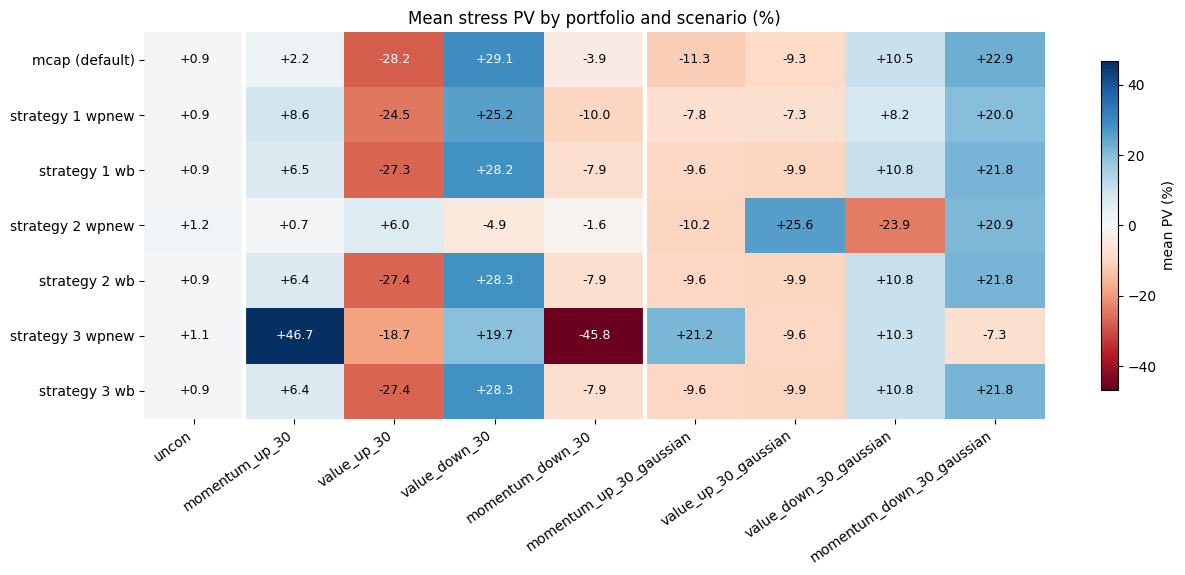

In [104]:

vals = pv_table.to_numpy()
vmax = np.abs(vals).max()

fig, ax = plt.subplots(figsize=(1.1 * pv_table.shape[1] + 3, 0.55 * pv_table.shape[0] + 2))
im = ax.imshow(vals, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(pv_table.shape[1]), pv_table.columns, rotation=35, ha='right')
ax.set_yticks(range(pv_table.shape[0]), pv_table.index)
for spine in ax.spines.values():
    spine.set_visible(False)
for x in (0.5, 0.5 + len(scenarios)):          # separators between the three blocks
    ax.axvline(x, color='white', lw=3)
for i in range(pv_table.shape[0]):
    for j in range(pv_table.shape[1]):
        v = vals[i, j]
        ax.text(j, i, f"{v:+.1f}", ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 * vmax else 'black')

fig.colorbar(im, ax=ax, label='mean PV (%)', shrink=0.85)
ax.set_title('Mean stress PV by portfolio and scenario (%)')
fig.tight_layout()
plt.show()

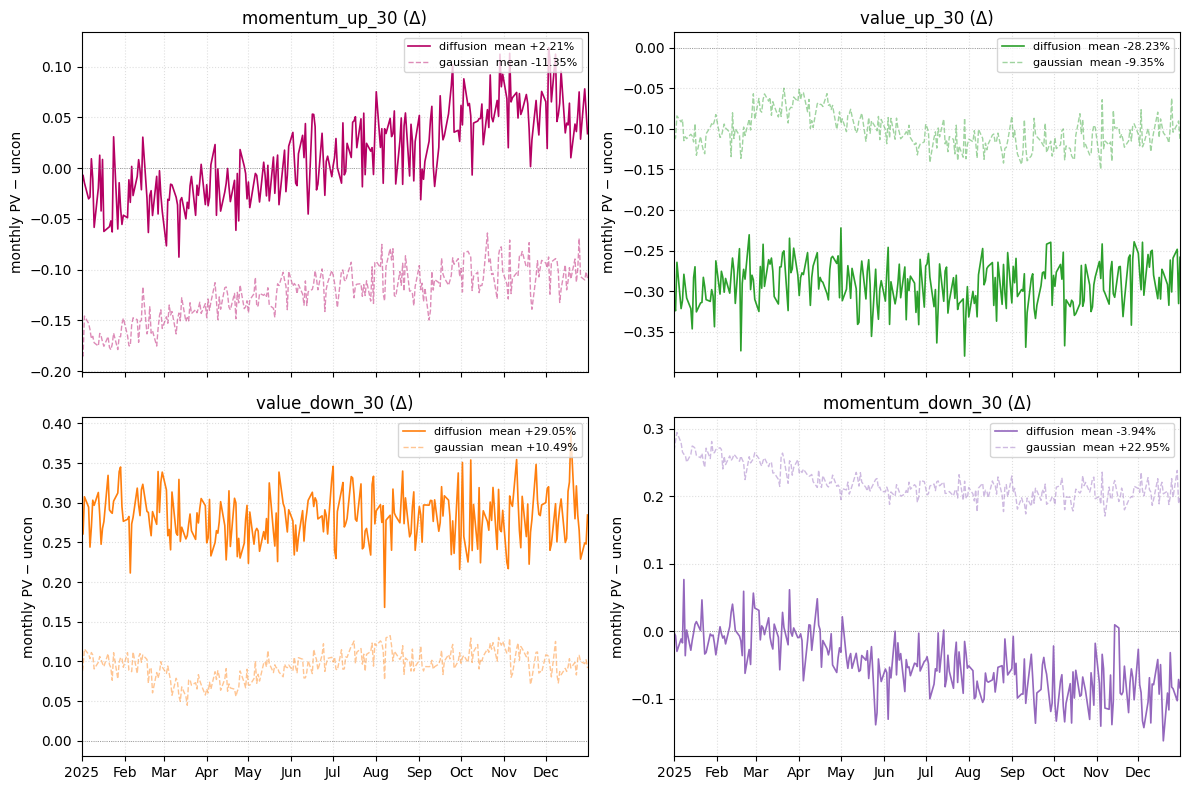

In [102]:
# plot 1: stress portfolio PV delta vs uncon, one subplot per scenario (independent y-scale),
# diffusion (solid) vs same-named gaussian baseline (dashed, faint)
import matplotlib.dates as mdates

xlim = (uncon_pv['date'].min(), uncon_pv['date'].max())   # follow the data range

n = len(scenarios)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                         sharex=True, sharey=False)   # each scenario autoscales y
axes = np.atleast_1d(axes).ravel()
for ax, name, color in zip(axes, scenarios, COLORS):
    pv, pv_g = stress_pvs[name], stress_pvs_g[name]
    delta   = pv['pv'].values   - uncon_pv['pv'].values
    delta_g = pv_g['pv'].values - uncon_pv['pv'].values
    ax.plot(pv['date'], delta, color=color, lw=1.2,
            label=f"diffusion  mean {pv['pv'].mean() * 100:+.2f}%")
    ax.plot(pv_g['date'], delta_g, color=color, lw=1.0, ls="--", alpha=0.45,
            label=f"gaussian  mean {pv_g['pv'].mean() * 100:+.2f}%")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"{name} (Δ)")
    ax.set_ylabel("monthly PV − uncon")
    ax.grid(True, ls=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(*xlim)
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
for ax in axes[n:]:                # hide unused panels
    ax.set_visible(False)
fig.tight_layout()
plt.show()

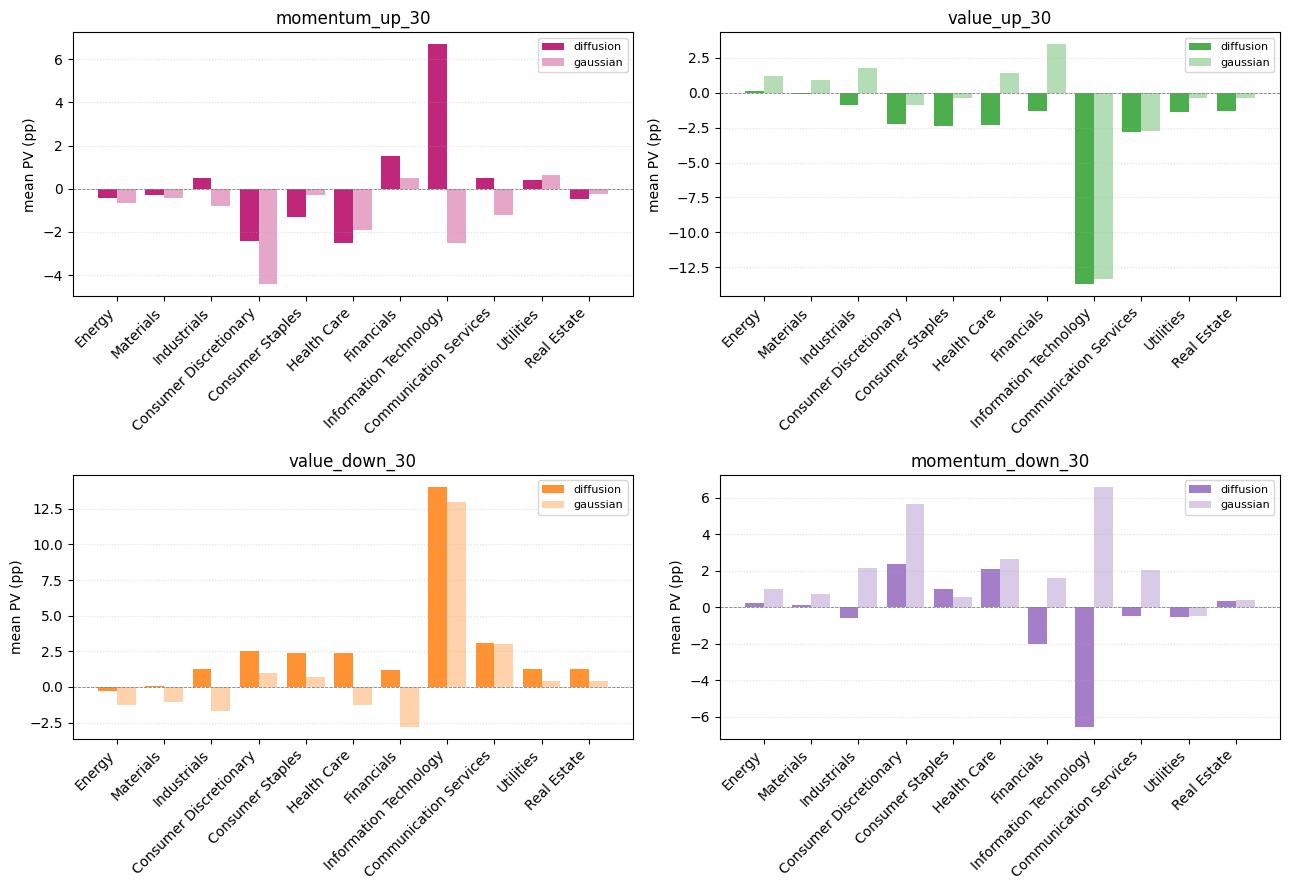

In [103]:
# plot 2: per-sector mean PV, one subplot per scenario (independent y-scale),
# diffusion (solid) vs same-named gaussian baseline (faint), grouped bars
means   = {name: sp.groupby('gics_name')['pv'].mean() for name, sp in sector_pvs.items()}
means_g = {name: sp.groupby('gics_name')['pv'].mean() for name, sp in sector_pvs_g.items()}
present = set().union(*(m.index for m in list(means.values()) + list(means_g.values())))
sectors = [s for s in gics_map.values() if s in present]    # keep GICS order

n = len(scenarios)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows),
                         sharex=False, sharey=False)   # each subplot keeps its own x/y axis
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(sectors))
bw = 0.4                                                # bar width for each variant
for ax, name, color in zip(axes, scenarios, COLORS):
    vals   = [means[name].get(s, np.nan)   * 100 for s in sectors]
    vals_g = [means_g[name].get(s, np.nan) * 100 for s in sectors]
    ax.bar(x - bw / 2, vals,   width=bw, color=color, alpha=0.85, label="diffusion")
    ax.bar(x + bw / 2, vals_g, width=bw, color=color, alpha=0.35, label="gaussian")
    ax.set_title(name)
    ax.set_ylabel("mean PV (pp)")
    ax.axhline(0, color="grey", lw=0.6, ls="--")
    ax.grid(True, ls=":", alpha=0.4, axis='y')
    ax.set_xticks(x)
    ax.set_xticklabels(sectors, rotation=45, ha='right')
    ax.legend(fontsize=8)
for ax in axes[n:]:                # hide unused panels
    ax.set_visible(False)
fig.tight_layout()
plt.show()